# QGenAI BAS with Perceval + Merlin Autograd: Compact MZI and Repeated CNOT

This notebook keeps the BAS 2x2 Born-machine setup used by the SPSA notebook,
but trains the photonic circuits with Merlin/PyTorch autograd instead of
SPSA finite-difference gradients.

- Dataset: 2x2 Bars-and-Stripes target distribution.
- Photonic models: compact image-style MZI and repeated heralded-CNOT circuits.
- Quantum local backend: Merlin `QuantumLayer`.
- Gradient: Merlin autograd through the photonic simulator.
- Optimizer: PyTorch Adam with the same `TRAIN_STEPS` and `BASE_LR` as the
  classical 1-5 layer baselines.

Circuit definition in this variant:
- MZI: one fixed-size encoding/state-preparation block followed by `n_layers`
  compact MZI blocks.
- CNOT: one encoding/state-preparation block followed by `n_layers` repeated
  CNOT blocks. Therefore 5 layers contain 5 repeated CNOT chains.

Note: the CNOT model uses `processor.linear_circuit()` so Merlin can differentiate
the optical network locally. This is not a QPU/BSCount run and does not perform
hardware postselection; `logical_success_mass` tracks how much probability lands
back in the logical dual-rail subspace. Repeated heralded CNOTs can become much
heavier than the original single-CNOT-chain notebook.


In [ ]:

import itertools
import json
import math
import time
from pathlib import Path
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

try:
    import pandas as pd
except Exception:
    pd = None

import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

import perceval as pcvl
from perceval.components import BS, PS
from merlin import QuantumLayer, ComputationSpace, MeasurementStrategy


# ============================================================
# Configuration
# ============================================================

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.set_default_dtype(torch.float64)

GRID_SHAPE = (2, 2)
N_QUBITS = GRID_SHAPE[0] * GRID_SHAPE[1]
N_MODES = 2 * N_QUBITS
N_STATES = 2 ** N_QUBITS

LAYERS = [1, 2, 3, 4, 5]
MODEL_KEYS = ["MZI", "CNOT", "CLASSICAL"]

TRAIN_STEPS = 150
BASE_LR = 0.04
INIT_SCALE = 0.18
GRAD_CLIP_NORM = 1.5
CLASSICAL_HIDDEN_DIM = 32

CNOT_CATALOG_NAME = "heralded cnot"
CNOT_PAIRS = [(0, 1), (1, 2), (2, 3)]

NLL_WEIGHT = 0.15
TV_WEIGHT = 0.05
EPS = 1e-12

HISTORY_DIR = Path(r"C:\Quantum")
AUTO_SAVE_HISTORY = True
AUTO_PLOT = True
DISPLAY_CIRCUITS = False


# ============================================================
# BAS dataset
# ============================================================

def bits_to_index(bits):
    index = 0
    for bit in bits:
        index = (index << 1) | int(bit)
    return int(index)


def index_to_bits(index):
    return tuple(int(bit) for bit in format(int(index), f"0{N_QUBITS}b"))


def index_to_image(index):
    return np.array(index_to_bits(index), dtype=float).reshape(GRID_SHAPE)


def is_bas_pattern(bits, grid_shape=GRID_SHAPE):
    image = np.array(bits, dtype=int).reshape(grid_shape)
    horizontal = all(np.all(image[row, :] == image[row, 0]) for row in range(grid_shape[0]))
    vertical = all(np.all(image[:, col] == image[0, col]) for col in range(grid_shape[1]))
    return horizontal or vertical


def build_bas_target_distribution():
    all_bits = list(itertools.product([0, 1], repeat=N_QUBITS))
    bas_bits = [bits for bits in all_bits if is_bas_pattern(bits)]
    bas_indices = np.array([bits_to_index(bits) for bits in bas_bits], dtype=np.int64)

    distribution = np.zeros(N_STATES, dtype=np.float64)
    distribution[bas_indices] = 1.0 / len(bas_indices)

    print("=" * 84)
    print("Dataset source: BAS")
    print(f"Grid: {GRID_SHAPE[0]}x{GRID_SHAPE[1]} -> {N_QUBITS} qubits, {N_MODES} photonic modes")
    print("Target distribution: uniform over Bars-and-Stripes patterns")
    print("Unique BAS patterns:", len(bas_indices), "/", N_STATES)
    print("BAS patterns:")
    for rank, idx in enumerate(bas_indices, 1):
        print(f"  {rank:02d}. {format(int(idx), f'0{N_QUBITS}b')} p={distribution[idx]:.4f}")
    print("=" * 84)

    return {
        "distribution": distribution,
        "source_name": f"BAS {GRID_SHAPE[0]}x{GRID_SHAPE[1]}",
        "bas_indices": bas_indices,
        "bas_bitstrings": [format(int(idx), f"0{N_QUBITS}b") for idx in bas_indices],
    }


DATASET = build_bas_target_distribution()
TARGET_DISTRIBUTION = DATASET["distribution"].astype(np.float64)
TARGET_SUPPORT = TARGET_DISTRIBUTION > 0
TARGET_TORCH = torch.tensor(TARGET_DISTRIBUTION, dtype=torch.float64)


def show_target_examples(max_images=24):
    bas_indices = DATASET["bas_indices"]
    n_show = min(max_images, len(bas_indices))
    cols = min(8, n_show)
    rows = math.ceil(n_show / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(1.35 * cols, 1.7 * rows))
    axes = np.array(axes).reshape(-1)

    for i, ax in enumerate(axes):
        if i >= n_show:
            ax.axis("off")
            continue
        index = int(bas_indices[i])
        ax.imshow(index_to_image(index), cmap="gray_r", vmin=0, vmax=1)
        ax.set_title(format(index, f"0{N_QUBITS}b"), fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(f"BAS target patterns {GRID_SHAPE[0]}x{GRID_SHAPE[1]}")
    fig.tight_layout()
    plt.show()


if AUTO_PLOT:
    show_target_examples()


# ============================================================
# Distribution objective and metrics
# ============================================================

def normalize_distribution_np(values):
    values = np.asarray(values, dtype=np.float64)
    total = float(values.sum())
    if total <= EPS:
        return np.ones_like(values) / len(values)
    return values / total


def objective_np(generated):
    generated = normalize_distribution_np(np.maximum(generated, EPS))
    target = normalize_distribution_np(TARGET_DISTRIBUTION)
    midpoint = 0.5 * (generated + target)
    support_target = target > 0
    support_generated = generated > 0
    kl_t_m = np.sum(target[support_target] * (np.log(target[support_target] + EPS) - np.log(midpoint[support_target] + EPS)))
    kl_g_m = np.sum(generated[support_generated] * (np.log(generated[support_generated] + EPS) - np.log(midpoint[support_generated] + EPS)))
    js = 0.5 * kl_t_m + 0.5 * kl_g_m
    tv = 0.5 * np.sum(np.abs(target - generated))
    weights = target[support_target] / target[support_target].sum()
    nll = -np.sum(weights * np.log(generated[support_target] + EPS))
    return float(js + NLL_WEIGHT * nll + TV_WEIGHT * tv)


def torch_objective(generated, target=TARGET_TORCH):
    generated = torch.clamp(generated, min=EPS)
    generated = generated / torch.clamp(generated.sum(), min=EPS)
    target = torch.clamp(target.to(generated.device, dtype=generated.dtype), min=0.0)
    target = target / torch.clamp(target.sum(), min=EPS)
    midpoint = 0.5 * (generated + target)
    support_target = target > 0
    support_generated = generated > 0
    kl_t_m = torch.sum(target[support_target] * (torch.log(target[support_target] + EPS) - torch.log(midpoint[support_target] + EPS)))
    kl_g_m = torch.sum(generated[support_generated] * (torch.log(generated[support_generated] + EPS) - torch.log(midpoint[support_generated] + EPS)))
    js = 0.5 * kl_t_m + 0.5 * kl_g_m
    tv = 0.5 * torch.sum(torch.abs(target - generated))
    weights = target[support_target] / target[support_target].sum()
    nll = -torch.sum(weights * torch.log(generated[support_target] + EPS))
    return js + NLL_WEIGHT * nll + TV_WEIGHT * tv


def metrics_np(generated, aux=None):
    generated = normalize_distribution_np(generated)
    target = normalize_distribution_np(TARGET_DISTRIBUTION)
    support_target = target > 0
    midpoint = 0.5 * (generated + target)
    support_generated = generated > 0

    kl_t_g = np.sum(target[support_target] * (np.log(target[support_target] + EPS) - np.log(generated[support_target] + EPS)))
    kl_t_m = np.sum(target[support_target] * (np.log(target[support_target] + EPS) - np.log(midpoint[support_target] + EPS)))
    kl_g_m = np.sum(generated[support_generated] * (np.log(generated[support_generated] + EPS) - np.log(midpoint[support_generated] + EPS)))
    js = 0.5 * kl_t_m + 0.5 * kl_g_m
    tv = 0.5 * np.sum(np.abs(target - generated))
    weights = target[support_target] / target[support_target].sum()
    nll = -np.sum(weights * np.log(generated[support_target] + EPS))
    target_mass = float(generated[support_target].sum())
    generated_support = generated > 1e-6
    mode_coverage = int(np.logical_and(generated_support, support_target).sum())
    entropy = float(-np.sum(generated[generated > 0] * np.log(generated[generated > 0] + EPS)))

    out = {
        "loss": objective_np(generated),
        "js_divergence": float(js),
        "kl_target_generated": float(kl_t_g),
        "total_variation_distance": float(tv),
        "negative_log_likelihood": float(nll),
        "target_support_probability": target_mass,
        "mode_coverage": mode_coverage,
        "target_support_modes": int(support_target.sum()),
        "entropy": entropy,
    }
    if aux:
        out.update(aux)
    return out


# ============================================================
# Photonic circuit builders
# ============================================================

def add_encoding_layer(processor):
    """Image-style encoding/state-preparation block shared by MZI and CNOT.

    This keeps the Born-machine setup: there is no sample-by-sample classical
    input. The parameters named enc_x* are learned state-preparation angles.
    Visually this corresponds to the red "Encoding Layer" block in the reference
    diagram: local BS -> phase -> local BS on each dual-rail qubit.
    """
    names = []
    for qubit in range(N_QUBITS):
        processor.add(2 * qubit, BS.Ry())
        name = f"enc_x{qubit}"
        processor.add(2 * qubit + 1, PS(phi=pcvl.P(name)))
        names.append(name)
        processor.add(2 * qubit, BS.Ry())
    return names


def add_compact_mzi_layer(processor, layer):
    """One compact MZI layer, matching the blue highlighted block.

    A layer is now intentionally small:
    phase bank -> odd-neighbor BS mesh -> phase bank -> even-neighbor BS mesh.
    There is no extra readout macro-layer.
    """
    names = []

    for mode in range(N_MODES):
        name = f"mzi_l{layer}_w_{mode}"
        processor.add(mode, PS(phi=pcvl.P(name)))
        names.append(name)

    for mode in range(1, N_MODES - 1, 2):
        name = f"mzi_l{layer}_odd_bs_{mode}"
        processor.add((mode, mode + 1), BS.Ry(theta=pcvl.P(name)))
        names.append(name)

    for mode in range(N_MODES):
        name = f"mzi_l{layer}_inter_{mode}"
        processor.add(mode, PS(phi=pcvl.P(name)))
        names.append(name)

    for mode in range(0, N_MODES - 1, 2):
        name = f"mzi_l{layer}_even_bs_{mode}"
        processor.add((mode, mode + 1), BS.Ry(theta=pcvl.P(name)))
        names.append(name)

    return names


def add_cnot_layer(processor, layer):
    """One repeated CNOT layer, matching the provided CNOT diagram.

    Every call adds trainable local photonic gates, one full q0->q1->q2->q3
    heralded CNOT chain, and post-CNOT trainable phases/local BS gates.
    Therefore n_layers=5 contains five CNOT chains.
    """
    names = []

    for mode in range(N_MODES):
        name = f"cnot_l{layer}_w_{mode}"
        processor.add(mode, PS(phi=pcvl.P(name)))
        names.append(name)

    for qubit in range(N_QUBITS):
        name = f"cnot_l{layer}_local_bs_{qubit}"
        processor.add(2 * qubit, BS.Ry(theta=pcvl.P(name)))
        names.append(name)

    add_cnot_block(processor)

    for mode in range(1, N_MODES - 1):
        name = f"cnot_l{layer}_inter_{mode}"
        processor.add(mode, PS(phi=pcvl.P(name)))
        names.append(name)

    for qubit in range(N_QUBITS):
        name = f"cnot_l{layer}_out_bs_{qubit}"
        processor.add(2 * qubit, BS.Ry(theta=pcvl.P(name)))
           names.append(name)

    return names


def add_cnot_block(processor):
    for control, target in CNOT_PAIRS:
        if control >= N_QUBITS or target >= N_QUBITS:
            continue
        mapping = (2 * control, 2 * control + 1, 2 * target, 2 * target + 1)
        processor.add(mapping, pcvl.catalog[CNOT_CATALOG_NAME].build_processor())


def build_mzi_processor(n_layers):
    processor = pcvl.Processor("SLOS", N_MODES)
    param_names = []
    param_names.extend(add_encoding_layer(processor))
    for layer in range(1, n_layers + 1):
        param_names.extend(add_compact_mzi_layer(processor, layer))
    processor.with_input(pcvl.BasicState([1, 0] * N_QUBITS))
    return processor, param_names


def build_cnot_processor(n_layers):
    processor = pcvl.Processor("SLOS", N_MODES)
    param_names = []
    param_names.extend(add_encoding_layer(processor))

    for layer in range(1, n_layers + 1):
        param_names.extend(add_cnot_layer(processor, layer))

    processor.with_input(pcvl.BasicState([1, 0] * N_QUBITS))
    return processor, param_names


def display_reference_circuit(model_key="MZI", n_layers=1, recursive=False):
    if model_key.upper() == "MZI":
        processor, _ = build_mzi_processor(n_layers)
    elif model_key.upper() == "CNOT":
        processor, _ = build_cnot_processor(n_layers)
    else:
        raise ValueError("model_key must be 'MZI' or 'CNOT'")
    pcvl.pdisplay(processor, recursive=recursive)
    return processor


if DISPLAY_CIRCUITS:
    display_reference_circuit("MZI", n_layers=1, recursive=False)
    display_reference_circuit("CNOT", n_layers=1, recursive=False)


# ============================================================
# Merlin autograd Born machines
# ============================================================

def parameter_prefixes_for(model_key):
    if model_key == "MZI":
        return ["enc_", "mzi_l"]
    if model_key == "CNOT":
        return ["enc_", "cnot_l"]
    raise ValueError(model_key)


def make_input_state_for_circuit(circuit):
    state = [1, 0] * N_QUBITS
    if circuit.m > len(state):
        state = state + [0] * (circuit.m - len(state))
    return state


def output_key_to_logical_index(key):
    if len(key) < N_MODES:
        return None
    logical = tuple(int(v) for v in key[:N_MODES])
    bits = []
    for qubit in range(N_QUBITS):
        zero_mode = logical[2 * qubit]
        one_mode = logical[2 * qubit + 1]
        if zero_mode + one_mode != 1:
            return None
        bits.append(one_mode)
    return bits_to_index(bits)


class MerlinPhotonicBornMachine(nn.Module):
    def __init__(self, model_key, n_layers):
        super().__init__()
        self.model_key = model_key
        self.n_layers = int(n_layers)

        if model_key == "MZI":
            processor, param_names = build_mzi_processor(n_layers)
        elif model_key == "CNOT":
            processor, param_names = build_cnot_processor(n_layers)
        else:
            raise ValueError(model_key)

        circuit = processor.linear_circuit()
        self.param_names = list(param_names)
        self.circuit_modes = int(circuit.m)
        self.input_state = make_input_state_for_circuit(circuit)
        self.n_photons = int(sum(self.input_state))

        self.quantum = QuantumLayer(
            input_size=0,
            circuit=circuit,
            input_state=self.input_state,
            n_photons=self.n_photons,
            input_parameters=[],
            trainable_parameters=parameter_prefixes_for(model_key),
            measurement_strategy=MeasurementStrategy.probs(ComputationSpace.UNBUNCHED),
            dtype=torch.float64,
        )
        self._initialize_parameters()
        self._build_logical_map()

    def _initialize_parameters(self):
        torch.manual_seed(SEED + 30_000 + len(self.param_names) + self.n_layers)
        for param in self.quantum.parameters():
            with torch.no_grad():
                param.uniform_(-INIT_SCALE, INIT_SCALE)

    def _build_logical_map(self):
        keys = self.quantum.output_keys
        logical_indices = []
        for key in keys:
            idx = output_key_to_logical_index(key)
            logical_indices.append(-1 if idx is None else int(idx))
        self.register_buffer("logical_map", torch.tensor(logical_indices, dtype=torch.long))
        self.output_key_count = len(keys)

    def forward_distribution(self):
        probs = self.quantum()
        if probs.dim() == 2:
            probs = probs.squeeze(0)
        probs = torch.clamp(probs, min=0.0)

        dist = torch.zeros(N_STATES, dtype=probs.dtype, device=probs.device)
        mask = self.logical_map >= 0
        if mask.any():
            dist.index_add_(0, self.logical_map[mask], probs[mask])

        logical_mass = dist.sum()
        uniform = torch.full_like(dist, 1.0 / N_STATES)
        dist_norm = torch.where(
            logical_mass > EPS,
            dist / torch.clamp(logical_mass, min=EPS),
            uniform,
        )
        aux = {
            "logical_success_mass": float(logical_mass.detach().cpu()),
            "raw_result_count": int(self.output_key_count),
            "circuit_modes": int(self.circuit_modes),
            "n_photons": int(self.n_photons),
        }
        return dist_norm, aux

    def forward(self):
        dist, _ = self.forward_distribution()
        return dist


def train_merlin_photonic_model(model_key, n_layers):
    model = MerlinPhotonicBornMachine(model_key, n_layers)
    optimizer = optim.Adam(model.parameters(), lr=BASE_LR)

    history = {
        "task": "BAS photonic Born Machine without encoding",
        "dataset": {
            "source": DATASET["source_name"],
            "grid_shape": list(GRID_SHAPE),
            "n_qubits": N_QUBITS,
            "n_modes": N_MODES,
            "n_states": N_STATES,
            "unique_target_patterns": int(TARGET_SUPPORT.sum()),
        },
        "model_key": model_key,
        "model_label": f"{model_key} Perceval + Merlin autograd Born Machine",
        "layers": int(n_layers),
        "encoding": "None. Fixed dual-rail input plus fixed BS state preparation.",
        "simulator": "Merlin QuantumLayer over processor.linear_circuit()",
        "optimizer": "PyTorch Adam with Merlin autograd gradients",
        "learning_rate": float(BASE_LR),
        "train_steps": int(TRAIN_STEPS),
        "cnot_catalog_name": CNOT_CATALOG_NAME if model_key == "CNOT" else None,
        "trainable_parameters": int(sum(p.numel() for p in model.parameters())),
        "parameter_names": model.param_names,
        "circuit_modes": int(model.circuit_modes),
        "input_state": list(model.input_state),
        "step": [],
        "loss": [],
        "js_divergence": [],
        "kl_target_generated": [],
        "total_variation_distance": [],
        "negative_log_likelihood": [],
        "target_support_probability": [],
        "mode_coverage": [],
        "entropy": [],
        "logical_success_mass": [],
        "raw_result_count": [],
        "grad_norm": [],
        "step_time_s": [],
    }

    best = {"loss": float("inf"), "distribution": None, "metrics": None, "step": 0}
    start_time = time.time()

    for step in range(1, TRAIN_STEPS + 1):
        step_start = time.time()
        optimizer.zero_grad(set_to_none=True)
        dist, aux = model.forward_distribution()
        loss = torch_objective(dist)
        loss.backward()
        grad_norm = float(torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM))
        optimizer.step()

        with torch.no_grad():
            dist_eval, aux_eval = model.forward_distribution()
            dist_np = dist_eval.detach().cpu().numpy()
            metrics = metrics_np(dist_np, aux_eval)

        if metrics["loss"] < best["loss"]:
            best = {
                "loss": metrics["loss"],
                "distribution": dist_np.copy(),
                "metrics": metrics.copy(),
                "step": step,
            }

        history["step"].append(step)
        for key in [
            "loss",
            "js_divergence",
            "kl_target_generated",
            "total_variation_distance",
            "negative_log_likelihood",
            "target_support_probability",
            "mode_coverage",
            "entropy",
        ]:
            history[key].append(float(metrics[key]))
        history["logical_success_mass"].append(float(metrics.get("logical_success_mass", np.nan)))
        history["raw_result_count"].append(int(metrics.get("raw_result_count", 0)))
        history["grad_norm"].append(float(grad_norm))
        history["step_time_s"].append(float(time.time() - step_start))

        if step == 1 or step % 25 == 0 or step == TRAIN_STEPS:
            print(
                f"{model_key:4s} {n_layers}L | step {step:03d}/{TRAIN_STEPS} | "
                f"loss={metrics['loss']:.5f} | JS={metrics['js_divergence']:.5f} | "
                f"TVD={metrics['total_variation_distance']:.5f} | "
                f"target_mass={metrics['target_support_probability']:.3f} | "
                f"coverage={metrics['mode_coverage']}/{metrics['target_support_modes']} | "
                f"logical_mass={metrics.get('logical_success_mass', np.nan):.3f} | "
                f"grad={grad_norm:.4f}"
            )

    training_time = time.time() - start_time
    generated = best["distribution"]
    target = TARGET_DISTRIBUTION
    history["timing"] = {
        "training_time_s": float(training_time),
        "mean_step_time_s": float(np.mean(history["step_time_s"])),
    }
    history["best_step"] = int(best["step"])
    history["final"] = {
        **best["metrics"],
        "generated_distribution": generated.tolist(),
        "target_distribution": target.tolist(),
        "top_generated_patterns": [
            {
                "rank": rank + 1,
                "index": int(idx),
                "bitstring": format(int(idx), f"0{N_QUBITS}b"),
                "generated_probability": float(generated[idx]),
                "target_probability": float(target[idx]),
                "is_target_pattern": bool(target[idx] > 0),
            }
            for rank, idx in enumerate(np.argsort(-generated)[:24])
        ],
    }

    if AUTO_SAVE_HISTORY:
        path = HISTORY_DIR / f"QGENAI-BAS-MERLIN-{model_key}-{n_layers}layers-history.json"
        with open(path, "w", encoding="utf-8") as file:
            json.dump(history, file, indent=2, ensure_ascii=False)
        history["history_path"] = str(path)
        print("Saved:", path)

    return {"model": model, "history": history}


# ============================================================
# Classical multi-layer distribution baselines
# ============================================================

class ClassicalMultilayerDistributionGenerator(nn.Module):
    def __init__(self, n_layers, hidden_dim=CLASSICAL_HIDDEN_DIM):
        super().__init__()
        self.n_layers = int(n_layers)
        self.latent = nn.Parameter(0.05 * torch.randn(1, hidden_dim, dtype=torch.float64))

        modules = []
        in_dim = hidden_dim
        for _layer in range(self.n_layers):
            modules.append(nn.Linear(in_dim, hidden_dim))
            modules.append(nn.SiLU())
            in_dim = hidden_dim
        modules.append(nn.Linear(in_dim, N_STATES))
        self.net = nn.Sequential(*modules).double()

    def forward(self):
        logits = self.net(self.latent).squeeze(0)
        return torch.softmax(logits, dim=0)


def train_classical_model(n_layers):
    torch.manual_seed(SEED + 20_000 + int(n_layers))
    model = ClassicalMultilayerDistributionGenerator(n_layers)
    optimizer = optim.Adam(model.parameters(), lr=BASE_LR)
    history = {
        "model_key": "CLASSICAL",
        "model_label": "Classical multi-layer distribution generator",
        "layers": int(n_layers),
        "optimizer": "Adam",
        "learning_rate": float(BASE_LR),
        "train_steps": int(TRAIN_STEPS),
        "hidden_dim": int(CLASSICAL_HIDDEN_DIM),
        "trainable_parameters": int(sum(p.numel() for p in model.parameters())),
        "epoch": [],
        "loss": [],
        "js_divergence": [],
        "total_variation_distance": [],
        "negative_log_likelihood": [],
        "target_support_probability": [],
        "mode_coverage": [],
        "entropy": [],
        "epoch_time_s": [],
    }

    start_time = time.time()
    best = {"loss": float("inf"), "distribution": None, "metrics": None, "epoch": 0}
    for epoch in range(1, TRAIN_STEPS + 1):
        epoch_start = time.time()
        optimizer.zero_grad(set_to_none=True)
        generated = model()
        loss = torch_objective(generated)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()

        dist = model().detach().cpu().numpy()
        metrics = metrics_np(dist)
        if metrics["loss"] < best["loss"]:
            best = {"loss": metrics["loss"], "distribution": dist.copy(), "metrics": metrics.copy(), "epoch": epoch}

        history["epoch"].append(epoch)
        for key in ["loss", "js_divergence", "total_variation_distance", "negative_log_likelihood", "target_support_probability", "mode_coverage", "entropy"]:
            history[key].append(float(metrics[key]))
        history["epoch_time_s"].append(float(time.time() - epoch_start))

        if epoch == 1 or epoch % 25 == 0 or epoch == TRAIN_STEPS:
            print(
                f"CLASSICAL {n_layers}L | epoch {epoch:03d}/{TRAIN_STEPS} | "
                f"loss={metrics['loss']:.5f} | JS={metrics['js_divergence']:.5f} | "
                f"target_mass={metrics['target_support_probability']:.3f} | "
                f"coverage={metrics['mode_coverage']}/{metrics['target_support_modes']}"
            )

    generated = best["distribution"]
    target_np = TARGET_DISTRIBUTION
    history["timing"] = {
        "training_time_s": float(time.time() - start_time),
        "mean_epoch_time_s": float(np.mean(history["epoch_time_s"])),
    }
    history["best_epoch"] = int(best["epoch"])
    history["final"] = {
        **best["metrics"],
        "generated_distribution": generated.tolist(),
        "target_distribution": target_np.tolist(),
        "top_generated_patterns": [
            {
                "rank": rank + 1,
                "index": int(idx),
                "bitstring": format(int(idx), f"0{N_QUBITS}b"),
                "generated_probability": float(generated[idx]),
                "target_probability": float(target_np[idx]),
                "is_target_pattern": bool(target_np[idx] > 0),
            }
            for rank, idx in enumerate(np.argsort(-generated)[:24])
        ],
    }

    if AUTO_SAVE_HISTORY:
        path = HISTORY_DIR / f"QGENAI-BAS-MERLIN-CLASSICAL-{n_layers}layers-history.json"
        with open(path, "w", encoding="utf-8") as file:
            json.dump(history, file, indent=2, ensure_ascii=False)
        history["history_path"] = str(path)
        print("Saved:", path)
    return {"model": model, "history": history}


# ============================================================
# Run training
# ============================================================

RESULTS = {}
for layer in LAYERS:
    for model_key in ["MZI", "CNOT"]:
        print("\n" + "=" * 92)
        print(f"Training {model_key} Perceval + Merlin autograd Born Machine | {layer} layer(s)")
        print("=" * 92)
        RESULTS[(model_key, layer)] = train_merlin_photonic_model(model_key, layer)

    print("\n" + "=" * 92)
    print(f"Training CLASSICAL multi-layer distribution generator | {layer} layer(s)")
    print("=" * 92)
    RESULTS[("CLASSICAL", layer)] = train_classical_model(layer)


# ============================================================
# Summary tables and plots
# ============================================================

summary_rows = []
for key, item in RESULTS.items():
    history = item["history"]
    final = history["final"]
    summary_rows.append({
        "model": history["model_label"],
        "model_key": history["model_key"],
        "layers": history.get("layers", key[1]),
        "trainable_parameters": history["trainable_parameters"],
        "loss": final["loss"],
        "js_divergence": final["js_divergence"],
        "kl_target_generated": final.get("kl_target_generated", np.nan),
        "total_variation_distance": final["total_variation_distance"],
        "negative_log_likelihood": final["negative_log_likelihood"],
        "target_support_probability": final["target_support_probability"],
        "mode_coverage": final["mode_coverage"],
        "target_support_modes": final["target_support_modes"],
        "entropy": final["entropy"],
        "logical_success_mass": final.get("logical_success_mass", np.nan),
        "training_time_s": history["timing"]["training_time_s"],
        "history_path": history.get("history_path", ""),
    })

if pd is not None:
    summary_df = pd.DataFrame(summary_rows)
    if AUTO_SAVE_HISTORY:
        path = HISTORY_DIR / "QGENAI-BAS-MERLIN-AUTOGRAD-summary.csv"
        summary_df.to_csv(path, index=False)
        print("Saved:", path)
    display(summary_df.sort_values(["layers", "model_key"]))
else:
    print(summary_rows)


def plot_metric_bars():
    rows = sorted(summary_rows, key=lambda r: (r["layers"], r["model_key"]))
    labels = [f"{row['model_key']} {row['layers']}L" for row in rows]

    metrics = [
        ("loss", "Objective loss", "lower is better"),
        ("js_divergence", "JS divergence", "lower is better"),
        ("total_variation_distance", "TVD", "lower is better"),
        ("negative_log_likelihood", "NLL", "lower is better"),
        ("target_support_probability", "Target support mass", "higher is better"),
        ("training_time_s", "Training time (s)", "lower is better"),
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    axes = axes.ravel()
    x = np.arange(len(rows))
    colors = [
        "#0072B2" if r["model_key"] == "MZI" else "#D55E00" if r["model_key"] == "CNOT" else "#009E73"
        for r in rows
    ]

    for ax, (metric, title, subtitle) in zip(axes, metrics):
        values = [row[metric] for row in rows]
        bars = ax.bar(x, values, color=colors, alpha=0.9)
        ax.set_title(f"{title}\n{subtitle}")
        ax.set_xticks(x, labels, rotation=45, ha="right")
        ax.grid(axis="y", alpha=0.25)
        for bar, value in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:.3f}", ha="center", va="bottom", fontsize=8)

    fig.suptitle(f"BAS {GRID_SHAPE[0]}x{GRID_SHAPE[1]} Merlin autograd Born Machine comparison", fontsize=14)
    fig.tight_layout()
    plt.show()


def plot_training_curves():
    fig, axes = plt.subplots(len(LAYERS), 1, figsize=(12, 3.4 * len(LAYERS)), sharex=False)
    if len(LAYERS) == 1:
        axes = [axes]
    for ax, layer in zip(axes, LAYERS):
        for model_key, color, style in [
            ("MZI", "#0072B2", "-"),
            ("CNOT", "#D55E00", "-"),
            ("CLASSICAL", "#009E73", "--"),
        ]:
            history = RESULTS[(model_key, layer)]["history"]
            x_key = "step" if "step" in history else "epoch"
            ax.plot(history[x_key], history["loss"], color=color, linestyle=style, label=f"{model_key} {layer}L")
        ax.set_title(f"Merlin autograd training objective | {layer} layer(s)")
        ax.set_xlabel("Step / epoch")
        ax.set_ylabel("Loss")
        ax.grid(alpha=0.25)
        ax.legend()
    fig.tight_layout()
    
    plt.show()


def plot_top_generated_images(result_key, top_k=12):
    history = RESULTS[result_key]["history"]
    top = history["final"]["top_generated_patterns"][:top_k]
    cols = min(top_k, 12)
    fig, axes = plt.subplots(1, cols, figsize=(1.35 * cols, 1.8))
    if cols == 1:
        axes = [axes]
    for ax, entry in zip(axes, top):
        ax.imshow(index_to_image(entry["index"]), cmap="gray_r", vmin=0, vmax=1)
        mark = "T" if entry["is_target_pattern"] else "-"
        ax.set_title(f"{entry['generated_probability']:.3f}\n{mark}", fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
    layer = history.get("layers", 0)
    fig.suptitle(f"Top generated BAS patterns | {history['model_key']} {layer}L")
    fig.tight_layout()
    plt.show()


def plot_distribution_overlay(result_key, top_k=16):    
    history = RESULTS[result_key]["history"]
    generated = np.array(history["final"]["generated_distribution"])
    target = TARGET_DISTRIBUTION
    important = set(np.argsort(-target)[:top_k].tolist())
    important.update(np.argsort(-generated)[:top_k].tolist())
    indices = list(sorted(important))
    x = np.arange(len(indices))

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(x - 0.18, target[indices], width=0.36, color="black", alpha=0.35, label="Target")
    ax.bar(x + 0.18, generated[indices], width=0.36, color="#0072B2", alpha=0.85, label="Generated")
    ax.set_xticks(x, [format(idx, f"0{N_QUBITS}b") for idx in indices], rotation=90, fontsize=8)
    ax.set_title(f"Target vs generated distribution | {history['model_key']} {history.get('layers', 0)}L")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    fig.tight_layout()
    maybe_savefig(fig, "target_vs_generated.png")
    plt.show()


if AUTO_PLOT:
    plot_metric_bars()
    plot_training_curves()
    for key in RESULTS:
        plot_top_generated_images(key, top_k=12)
        plot_distribution_overlay(key, top_k=16)


IndentationError: unexpected indent (2996762786.py, line 316)

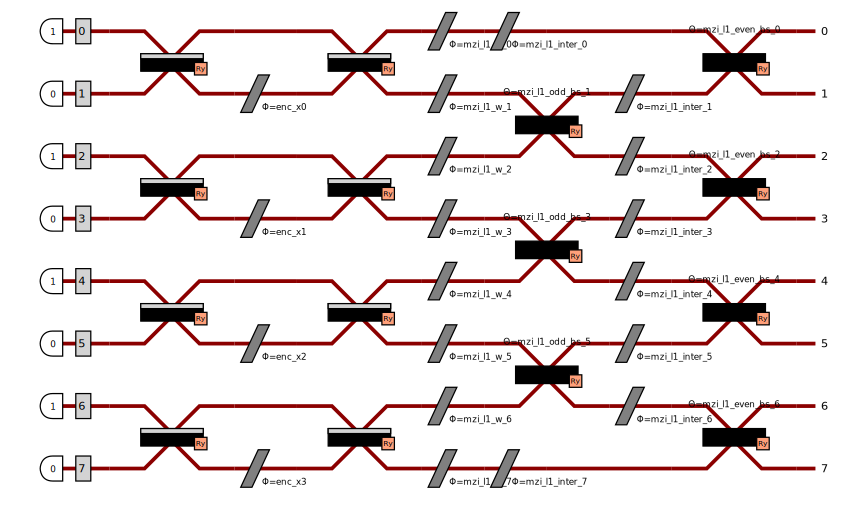

In [7]:
import perceval as pcvl

# Xem MZI 1 layer
mzi_1, mzi_params_1 = build_mzi_processor(n_layers=1)
pcvl.pdisplay(mzi_1, recursive=True)

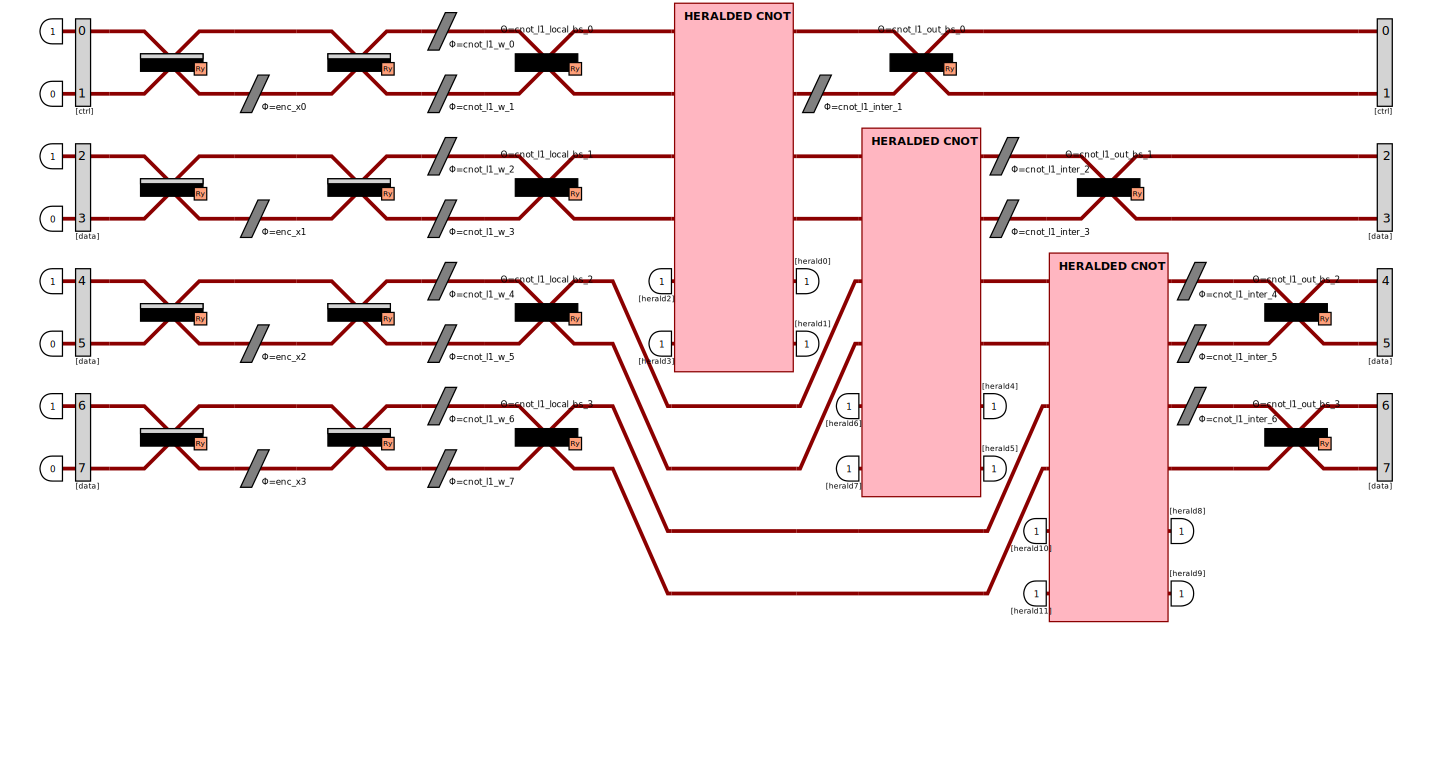

In [8]:
cnot_1, cnot_params_1 = build_cnot_processor(n_layers=1)
pcvl.pdisplay(cnot_1, recursive=False)